# GraphSAGE - Link Prediction WITHOUT BGE-M3

This notebook implements a **GraphSAGE** model for link prediction **without using BGE-M3 embeddings**.

## GraphSAGE vs GCN
- **GCN**: Uses normalized adjacency, requires full graph adjacency for message passing
- **GraphSAGE**: Uses neighborhood sampling + aggregation (mean, max, LSTM), supports inductive learning

## Overview
- **Task**: Link prediction
- **Architecture**: Learnable embeddings + 2-layer GraphSAGE + dot-product decoder
- **Input**: Randomly initialized learnable embeddings (NOT BGE-M3)
- **Train/Test Split**: Per-node 80/20 split
- **Metrics**: AUC-ROC on held-out test edges

## References
- Hamilton et al. (2017): "Inductive Representation Learning on Large Graphs"

In [1]:
import os, random, pickle
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv
from torch_geometric.utils import negative_sampling
from sklearn.metrics import roc_auc_score
import warnings
warnings.filterwarnings('ignore')

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

# Paths
REPO_ROOT = r'C:\programming\github-repos\graph-ending'
CACHE_DIR = os.path.join(REPO_ROOT, 'WikiCS', 'custom-wiki', 'cache', 'graphSAGE')
EVAL_CACHE = os.path.join(REPO_ROOT, 'WikiCS', 'custom-wiki', 'cache', 'eval-1')
os.makedirs(CACHE_DIR, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cpu


## Step 1 — Load Graph Data

In [2]:
# Load graph from eval-1 split
with open(os.path.join(EVAL_CACHE, 'train_test_split.pkl'), 'rb') as f:
    split_data = pickle.load(f)

G_train = split_data['G_train']
E_test = split_data['E_test']
G_train_und = G_train.to_undirected()

valid_nodes = list(G_train_und.nodes())
node_to_idx = {n: i for i, n in enumerate(valid_nodes)}
idx_to_node = {i: n for n, i in node_to_idx.items()}
N = len(valid_nodes)

train_edges = [
    (node_to_idx[u], node_to_idx[v])
    for u, v in G_train_und.edges()
    if u in node_to_idx and v in node_to_idx
]
edge_index = torch.tensor(train_edges, dtype=torch.long).t().contiguous()

test_pos_edges = [
    (node_to_idx[u], node_to_idx[v])
    for u, v in E_test
    if u in node_to_idx and v in node_to_idx
]
test_pos_edge_index = torch.tensor(test_pos_edges, dtype=torch.long).t().contiguous()

print(f'Nodes: {N}, Train edges: {edge_index.size(1)}, Test edges: {test_pos_edge_index.size(1)}')
print(f'\nNOTE: No BGE-M3 embeddings used - learning from graph structure only.')

Nodes: 11701, Train edges: 181315, Test edges: 63106

NOTE: No BGE-M3 embeddings used - learning from graph structure only.


## Step 2 — Define GraphSAGE Model

In [3]:
class GraphSAGELinkPredictor(torch.nn.Module):
    def __init__(self, num_nodes, embedding_dim, hidden_channels, out_channels):
        super().__init__()
        # Learnable embeddings (random init, NOT BGE-M3)
        self.node_embeddings = torch.nn.Embedding(num_nodes, embedding_dim)
        torch.nn.init.xavier_uniform_(self.node_embeddings.weight)
        
        # GraphSAGE layers (mean aggregation)
        self.conv1 = SAGEConv(embedding_dim, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, out_channels)
        
    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.conv2(x, edge_index)
        return x
    
    def encode(self):
        return self.node_embeddings.weight
    
    def decode(self, z, edge_index):
        return (z[edge_index[0]] * z[edge_index[1]]).sum(dim=1)


EMBEDDING_DIM, HIDDEN_DIM, OUTPUT_DIM = 64, 128, 64
model = GraphSAGELinkPredictor(N, EMBEDDING_DIM, HIDDEN_DIM, OUTPUT_DIM).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

edge_index = edge_index.to(device)
test_pos_edge_index = test_pos_edge_index.to(device)

print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')
print(f'Architecture: Embed({EMBEDDING_DIM}) -> SAGE({HIDDEN_DIM}) -> Out({OUTPUT_DIM})')

Parameters: 781,824
Architecture: Embed(64) -> SAGE(128) -> Out(64)


## Step 3 — Training Loop

In [4]:
def train_step():
    model.train()
    optimizer.zero_grad()
    z = model(model.encode(), edge_index)
    neg_edge_index = negative_sampling(edge_index, num_nodes=N, num_neg_samples=edge_index.size(1))
    pos_scores = model.decode(z, edge_index)
    neg_scores = model.decode(z, neg_edge_index)
    scores = torch.cat([pos_scores, neg_scores])
    labels = torch.cat([torch.ones_like(pos_scores), torch.zeros_like(neg_scores)])
    loss = F.binary_cross_entropy_with_logits(scores, labels)
    loss.backward()
    optimizer.step()
    return loss.item()


def eval_step():
    model.eval()
    with torch.no_grad():
        z = model(model.encode(), edge_index)
        neg_edge_index = negative_sampling(test_pos_edge_index, num_nodes=N, num_neg_samples=test_pos_edge_index.size(1))
        pos_scores = torch.sigmoid(model.decode(z, test_pos_edge_index)).cpu().numpy()
        neg_scores = torch.sigmoid(model.decode(z, neg_edge_index)).cpu().numpy()
        scores = np.concatenate([pos_scores, neg_scores])
        labels = np.concatenate([np.ones(len(pos_scores)), np.zeros(len(neg_scores))])
        return roc_auc_score(labels, scores)


patience, best_val_auc, epochs_no_improve = 15, 0, 0
max_epochs = 200
train_losses, val_aucs = [], []

print('Training GraphSAGE (no BGE-M3)...')
print('-' * 55)

for epoch in range(1, max_epochs + 1):
    loss = train_step()
    train_losses.append(loss)
    
    if epoch % 5 == 0:
        val_auc = eval_step()
        val_aucs.append(val_auc)
        print(f'Epoch {epoch:3d} | Loss: {loss:.4f} | Val AUC: {val_auc:.4f}')
        
        if val_auc > best_val_auc:
            best_val_auc = val_auc
            epochs_no_improve = 0
            best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            epochs_no_improve += 1
            
        if epochs_no_improve >= patience:
            print(f'Early stopping at epoch {epoch}')
            break

print('-' * 55)
print(f'Best Val AUC: {best_val_auc:.4f}')

Training GraphSAGE (no BGE-M3)...
-------------------------------------------------------
Epoch   5 | Loss: 0.6690 | Val AUC: 0.8051
Epoch  10 | Loss: 0.5887 | Val AUC: 0.7708
Epoch  15 | Loss: 0.5597 | Val AUC: 0.8039
Epoch  20 | Loss: 0.5487 | Val AUC: 0.8288
Epoch  25 | Loss: 0.5386 | Val AUC: 0.8401
Epoch  30 | Loss: 0.5276 | Val AUC: 0.8633
Epoch  35 | Loss: 0.5127 | Val AUC: 0.8785
Epoch  40 | Loss: 0.5068 | Val AUC: 0.8910
Epoch  45 | Loss: 0.5025 | Val AUC: 0.8929
Epoch  50 | Loss: 0.4961 | Val AUC: 0.8926
Epoch  55 | Loss: 0.4894 | Val AUC: 0.9072
Epoch  60 | Loss: 0.4865 | Val AUC: 0.9042
Epoch  65 | Loss: 0.4853 | Val AUC: 0.9107
Epoch  70 | Loss: 0.4823 | Val AUC: 0.9080
Epoch  75 | Loss: 0.4813 | Val AUC: 0.9109
Epoch  80 | Loss: 0.4821 | Val AUC: 0.9057
Epoch  85 | Loss: 0.4807 | Val AUC: 0.9135
Epoch  90 | Loss: 0.4803 | Val AUC: 0.9098
Epoch  95 | Loss: 0.4790 | Val AUC: 0.9161
Epoch 100 | Loss: 0.4802 | Val AUC: 0.9071
Epoch 105 | Loss: 0.4814 | Val AUC: 0.9163
Epoch 1

## Step 4 — Final Test Evaluation

In [5]:
# Load best model
model.load_state_dict(best_model_state)
model.to(device)

# Final test evaluation
test_auc = eval_step()
print(f'Final Test AUC: {test_auc:.4f}')

# Get final embeddings
model.eval()
with torch.no_grad():
    final_embeddings = model(model.encode(), edge_index).cpu().numpy()

print(f'Embeddings shape: {final_embeddings.shape}')

Final Test AUC: 0.9189
Embeddings shape: (11701, 64)


## Step 5 — Plot Training Curves

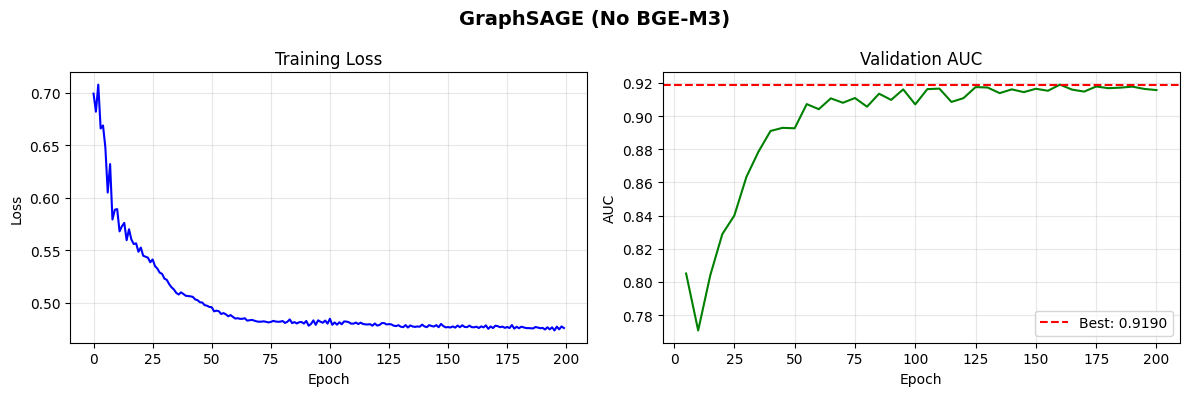

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(train_losses, color='blue')
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(True, alpha=0.3)

axes[1].plot(np.arange(5, len(val_aucs)*5+1, 5), val_aucs, color='green')
axes[1].axhline(y=best_val_auc, color='red', linestyle='--', label=f'Best: {best_val_auc:.4f}')
axes[1].set_title('Validation AUC')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('AUC')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('GraphSAGE (No BGE-M3)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(CACHE_DIR, 'graphsage_training_curve.png'), dpi=150)
plt.show()

## Step 6 — Save Results

In [7]:
results = {
    'test_auc': float(test_auc),
    'best_val_auc': float(best_val_auc),
    'train_losses': [float(l) for l in train_losses],
    'val_aucs': [float(a) for a in val_aucs],
    'final_embeddings': final_embeddings,
    'node_to_idx': node_to_idx,
    'idx_to_node': idx_to_node,
    'n_nodes': N,
    'uses_bge_m3': False,
}

with open(os.path.join(CACHE_DIR, 'graphsage_results.pkl'), 'wb') as f:
    pickle.dump(results, f)

print(f'Results saved to {CACHE_DIR}/graphsage_results.pkl')
print(f'\n{"=" * 55}')
print(f'SUMMARY - GraphSAGE (No BGE-M3)')
print(f'{"=" * 55}')
print(f'Architecture: Embed({EMBEDDING_DIM}) -> SAGE({HIDDEN_DIM}) -> Out({OUTPUT_DIM})')
print(f'BGE-M3 Used: NO (pure graph structure learning)')
print(f'Best Val AUC: {best_val_auc:.4f}')
print(f'Final Test AUC: {test_auc:.4f}')
print(f'{"=" * 55}')

Results saved to C:\programming\github-repos\graph-ending\WikiCS\custom-wiki\cache\graphSAGE/graphsage_results.pkl

SUMMARY - GraphSAGE (No BGE-M3)
Architecture: Embed(64) -> SAGE(128) -> Out(64)
BGE-M3 Used: NO (pure graph structure learning)
Best Val AUC: 0.9190
Final Test AUC: 0.9189
